In [1]:
import tensorflow as tf
import numpy as np
import re
import os

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()
    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)

    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor
def retrieve_dict(base_dir, filename):
    # Dictionary to hold costs organized by prefix (i)
    fidelity_dict = {}
    # Iterate through each subfolder in the base directory
    folder_names = os.listdir(base_dir)
    
    # Sort folders numerically or lexicographically
    folder_names.sort(key=lambda x: int(x.split('_')[0]))

    # Iterate through each subfolder in the base directory
    for folder_name_1 in folder_names:
        folder_path = os.path.join(base_dir, folder_name_1)
        if os.path.isdir(folder_path):
            # Extract the prefix for identifying the 'i' value
            prefix = folder_name_1.split('_')[0]
            folder_paths = os.listdir(folder_path)
            directories = [item for item in folder_paths if os.path.isdir(os.path.join(folder_path, item))]
            directories.sort(key=lambda x: float(x.split('_')[-1]))
            for folder_name_2 in directories:
                 
                 folder_path_2 = os.path.join(folder_path, folder_name_2)
                 cost_file_path = os.path.join(folder_path_2, filename)
            
                # Read the cost value from the cost.txt file
                 if os.path.exists(cost_file_path):
                        # Extract the complex number part using regular expression
                        tensor = parse_tensor_from_file(cost_file_path, 1)
                     
                        # Convert the extracted string to a complex number
                        for t in tensor.numpy():
                             # Get the real part and convert to float
                            float_value = 1-t.real
                            # if (float_value < 10e-4): continue
                            if prefix not in fidelity_dict:
                                fidelity_dict[prefix] = []
                            fidelity_dict[prefix].append(abs(float_value))
    
    return fidelity_dict

{'1': [0.0016047710905832124, 0.010095587165848574, 0.01881609762352998, 0.02778642801188136, 0.03702987253486789, 0.04657359867947619, 0.05644967896068387, 0.06669637475295198, 0.07736000861119596, 0.08849754099535545, 0.10018040459143807, 0.1125002485429678, 0.12557805530762733, 0.13957937641326978, 0.15474155708583426, 0.17142722182521097, 0.19024365431930013, 0.21236805607384868, 0.24082026808231627, 0.307439052757553], '2': [0.01379948677903764, 0.03836952667263838, 0.051953519952316674, 0.08114420401773514, 0.09831864524221423, 0.12067135268847806, 0.14508044016286337, 0.17148259422173495, 0.195341080767106, 0.22028160627350968, 0.243604074700697, 0.26975968634755465, 0.2973043784955336, 0.32709712210075725, 0.35769635452159343, 0.38494981576924936, 0.42394173378500744, 0.4635684735471872, 0.5084849445857091, 0.6052197857087154]}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


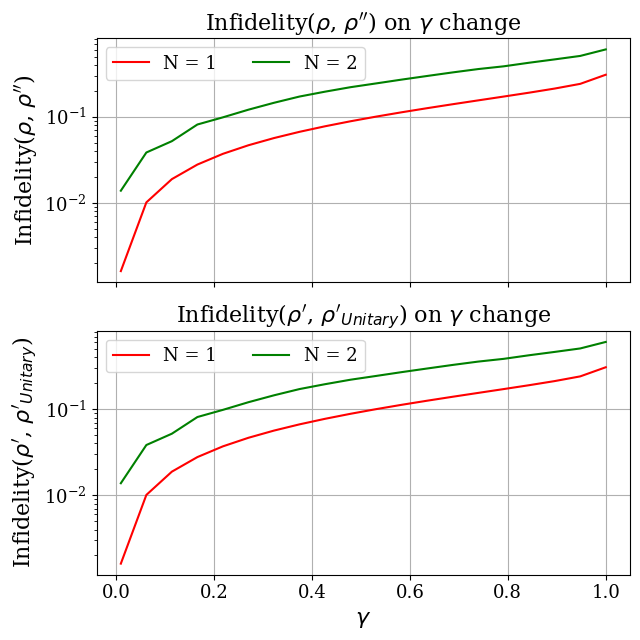

In [4]:
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt

def plot_fidelity(fidelity_dict1, fidelity_dict2, ylabel1, ylabel2, xlabel, xticks, file_name):
    # Set font family to serif
    plt.rc('font', family='serif')
    
    # Create a figure with two subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 6.5), sharex=True)
    colorList = ['r', 'g', 'b', 'magenta', 'orange']
    

    # Plot for the first fidelity dict (Top subplot)
    for i, (key, values) in enumerate(fidelity_dict1.items()):
        ax1.plot(xticks, values, label="N = " + key, color=colorList[i % len(colorList)]) 

    ax1.set_ylabel(ylabel1, fontsize=16)
    ax1.set_title(ylabel1 + ' on ' + xlabel + ' change', fontsize=16)
    ax1.set_yscale('log')  
    ax1.grid(True)
    ax1.legend(fontsize=13, ncol=2)
    
    # Plot for the second fidelity dict (Bottom subplot)
    for i, (key, values) in enumerate(fidelity_dict2.items()):
        ax2.plot(xticks, values, label="N = " + key, color=colorList[i % len(colorList)])  

    ax2.set_xlabel(xlabel, fontsize=16)  
    ax2.set_ylabel(ylabel2, fontsize=16)
    ax2.set_title(ylabel2 + ' on ' + xlabel + ' change', fontsize=16)
    #ax2.set_xscale('log')
    ax2.set_yscale('log')  
    ax2.grid(True)

    ax2.legend(fontsize=13, ncol=2)

    ax1.tick_params(axis='y', labelsize=13) 
    ax2.tick_params(axis='y', labelsize=13)

    ax1.tick_params(axis='x', labelsize=13)
    ax2.tick_params(axis='x', labelsize=13)

    # Save the figure
    plt.tight_layout()
    plt.savefig(f'../../docs/new_fig/{file_name}.png', format='png')
    plt.savefig(f'../../docs/new_fig/{file_name}.eps', format='eps')

    # Display the plot
    plt.show()

xticks = np.linspace(10e-3, 1, 20)
fidelity_dict_rho_rho3 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho_rho3.txt')
print(fidelity_dict_rho_rho3)
fidelity_dict_rho2_rho2 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho2_rho2.txt')
plot_fidelity(fidelity_dict_rho_rho3, fidelity_dict_rho2_rho2, "Infidelity($\\rho$, $\\rho''$)", "Infidelity($\\rho'$, $\\rho'_{Unitary}$)", '$\\gamma$', xticks, 'fidelity_rho-rho3_rho-rho2_2')